<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-ITAI-Final-project-AK/blob/main/Final_Project_balanced_credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project - Credit Card Fraud Detection


**Task 1: Problem Definition and Dataset Selection**
* **Problem:** Financial institutions lose billions annually to credit card fraud. Accurate classification helps mitigate losses while protecting user satisfaction.
* **Dataset:** Balanced Credit Card Dataset (`balanced_creditcard.csv`) with a 50/50 balance between fraudulent and legitimate records to eliminate bias.

**Task 2: Data Preprocessing and Exploration**

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (6, 4)

In [14]:
# Load dataset
df = pd.read_csv("balanced_creditcard.csv")
print(df.head())
print(df.describe())
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Records:", df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates()
print("Class Distribution:\n", df['Class'].value_counts())

         V1        V2        V3        V4        V5        V6        V7  \
0  1.984787 -1.937036  0.486613 -1.245536 -2.518536 -0.544524 -1.819244   
1 -0.613696  3.698772 -5.534941  5.620486  1.649263 -2.335145 -0.907188   
2  0.319007 -1.072867 -0.216146  1.494709 -0.627063 -0.761867  0.941687   
3 -6.682832 -2.714268 -5.774530  1.449792 -0.661836 -1.148650  0.849686   
4 -6.713407  3.921104 -9.746678  5.148263 -5.151563 -2.099389 -5.937767   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0 -0.074875 -0.659777  1.407038  ...  0.174011  0.889289  0.218248  0.492384   
1  0.706362 -3.747646 -4.230984  ...  0.319261 -0.471379 -0.075890 -0.667909   
2 -0.430272 -0.267431 -0.245992  ...  0.332521 -0.022461 -0.537691  0.452072   
3  0.433427 -1.315646 -2.796332  ...  0.220526  1.187013  0.335821  0.215683   
4  3.578780 -4.684952 -8.537758  ...  0.954272 -0.451086  0.127214 -0.339450   

        V25       V26       V27       V28    Amount  Class  
0 -0.58

/tmp/ipykernel_1057/447124966.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_1057/447124966.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1], palette='Set2')


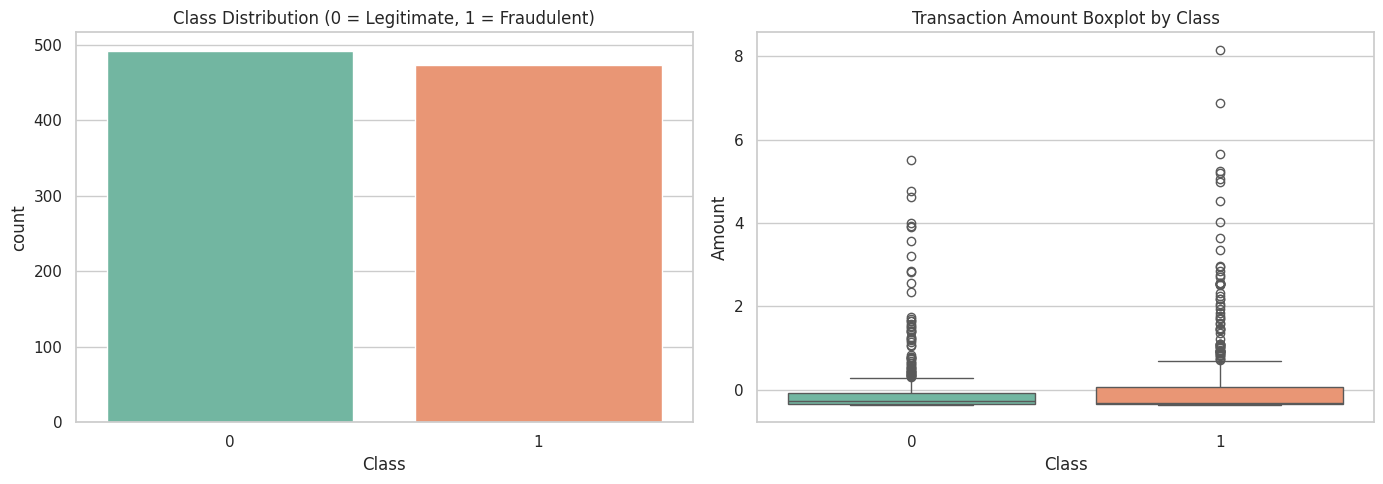

In [3]:
# Visualizations: Class distribution and Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Class', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Class Distribution (0 = Legitimate, 1 = Fraudulent)')

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Transaction Amount Boxplot by Class')
plt.tight_layout()
plt.show()

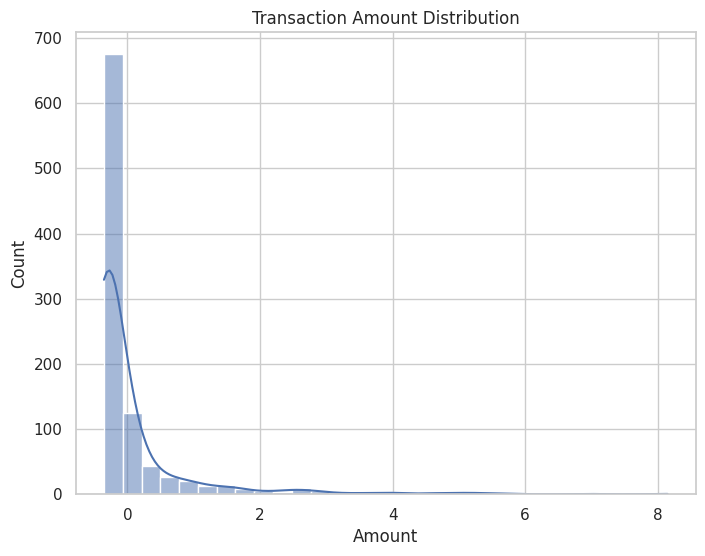

In [15]:
# Distribution of Transaction Amount
plt.figure(figsize=(8,6))

sns.histplot(df['Amount'],
             bins=30,
             kde=True)

plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.show()

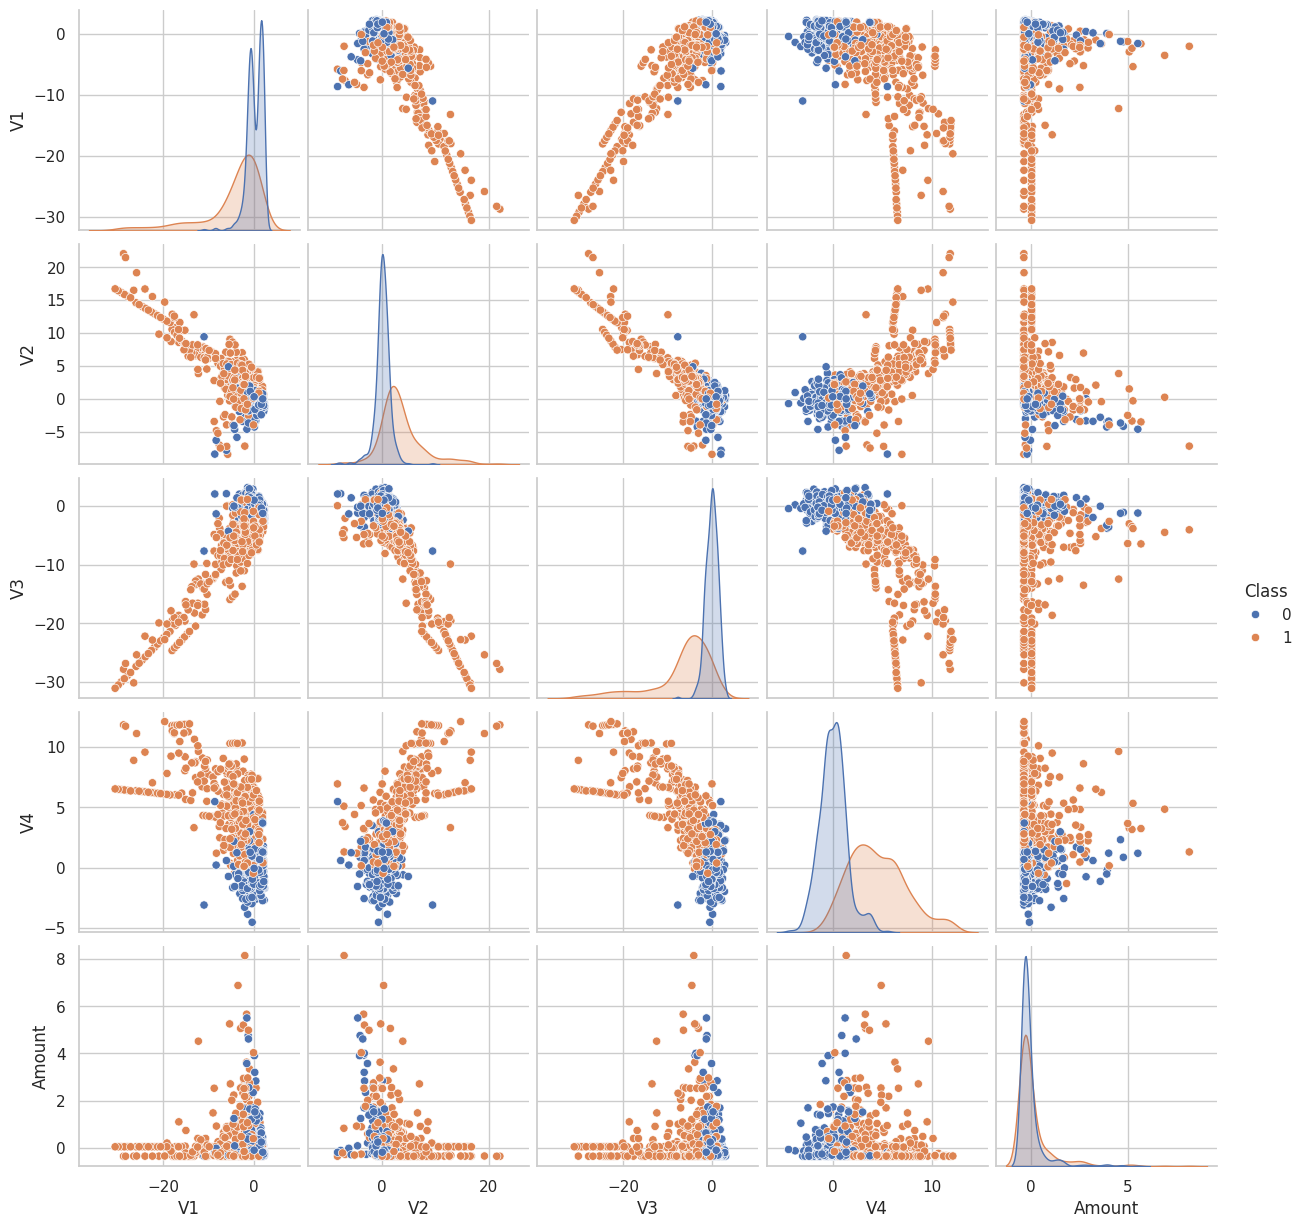

In [13]:
# Pairwise Relationship Visualization
selected_features = ['V1', 'V2', 'V3', 'V4', 'Amount', 'Class']
sns.pairplot(df[selected_features],
             hue='Class')

plt.show()

In [4]:
# Data Splitting and Feature Scaling
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit scaler on training amount column
X_train_scaled['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test_scaled['Amount'] = scaler.transform(X_test[['Amount']])

print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Training set shape: (772, 29), Test set shape: (193, 29)


**Task 3: Model Selection and Development**

We develop an optimized Random Forest Classifier with Hyperparameter Tuning.

In [5]:
# Hyperparameter Tuning using Grid Search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters Found:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

Best Parameters Found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [6]:
# Cross-Validation Robustness check
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5)
print(f"5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

5-Fold Cross-Validation Scores: [0.93548387 0.97419355 0.91558442 0.93506494 0.95454545]
Mean CV Accuracy: 0.9430


**Task 4: Model Evaluation and Optimization**

In [7]:
# Final predictions and evaluation
y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

print("=== Model Classification Report ===")
print(classification_report(y_test, y_pred))

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred):.4f}")
print(f"Recall Score: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

=== Model Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        98
           1       0.95      0.86      0.91        95

    accuracy                           0.91       193
   macro avg       0.92      0.91      0.91       193
weighted avg       0.92      0.91      0.91       193

Accuracy Score: 0.9119
Precision Score: 0.9535
Recall Score: 0.8632
F1 Score: 0.9061
ROC-AUC Score: 0.9647


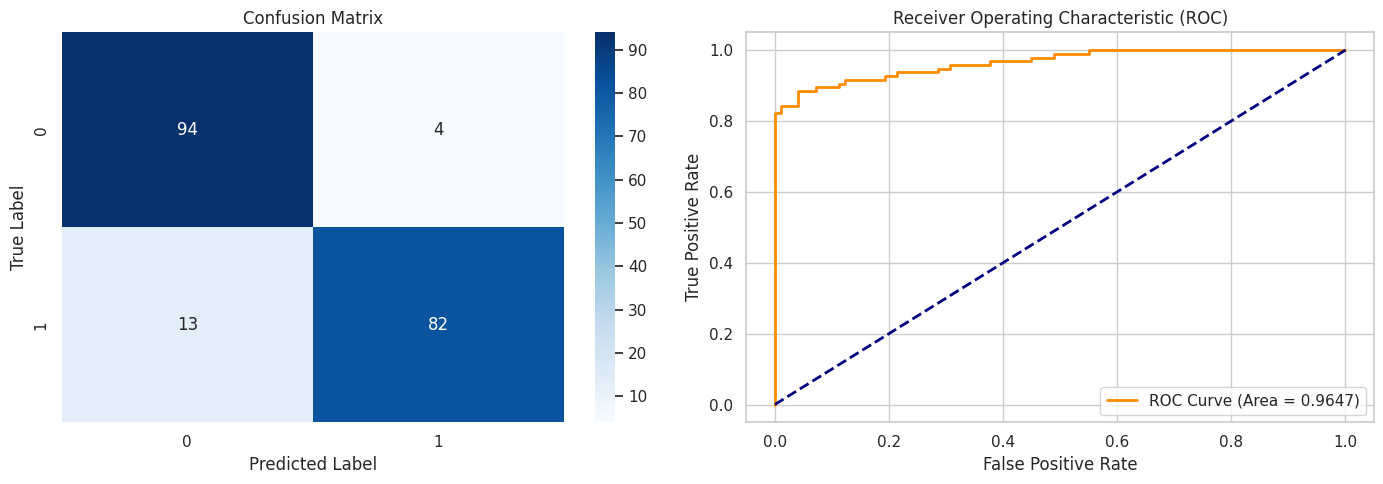

In [8]:
# Visualizing Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (Area = {roc_auc_score(y_test, y_prob):.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1057/2179972073.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='viridis')


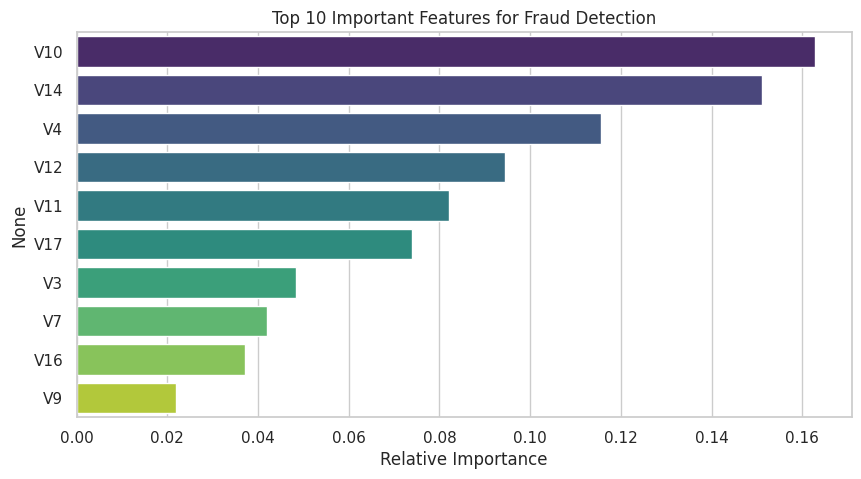

In [9]:
# Top 10 Feature Importances
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
features = X.columns

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
plt.title('Top 10 Important Features for Fraud Detection')
plt.xlabel('Relative Importance')
plt.show()

**Task 5: Model Deployment and Presentation**
Deploy the serialized model with an interactive User Interface widget.

In [10]:
# Save the model and scaler artifacts
joblib.dump(best_rf, 'optimized_fraud_model.pkl')
joblib.dump(scaler, 'amount_scaler.pkl')
print("Model and Scaler successfully saved!")

Model and Scaler successfully saved!


In [11]:
# Interactive prediction deployment widget
print("=== CREDIT CARD FRAUD INTERACTIVE PREDICTION TOOL ===")
amount_input = widgets.FloatText(value=120.0, description='Amount ($):')
predict_btn = widgets.Button(description='Analyze Transaction', button_style='info')
output_area = widgets.Output()

def run_inference(b):
    with output_area:
        output_area.clear_output()
        # Mimic sample layout using median values for latent V1-V28 vectors and scaled raw user amount
        test_sample = np.zeros((1, 29))
        scaled_amt = scaler.transform([[amount_input.value]])[0][0]
        test_sample[0, -1] = scaled_amt

        pred = best_rf.predict(test_sample)[0]
        prob = best_rf.predict_proba(test_sample)[0][1]

        if pred == 1:
            display(HTML(f"<h3 style='color:red;'>⚠️ FRAUD DETECTED! (Confidence: {prob*100:.2f}%)</h3>"))
        else:
            display(HTML(f"<h3 style='color:green;'>✅ TRANSACTION APPROVED (Legitimate confidence: {(1-prob)*100:.2f}%)</h3>"))

predict_btn.on_click(run_inference)
display(widgets.VBox([amount_input, predict_btn, output_area]))

=== CREDIT CARD FRAUD INTERACTIVE PREDICTION TOOL ===
